In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:

df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [17]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [18]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [19]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [22]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_test['Age']

In [23]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [24]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] # took only null values

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [28]:
X_train['Age'].isnull().sum()

np.int64(148)

In [ ]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values  # took random values 
# an amount of how much the NA are in that case 148

array([21. , 41. ,  7. , 20. , 17. , 11. , 20. , 27. , 20. , 36.5,  3. ,
       48. , 51. , 34. , 71. , 66. , 40. , 30. , 19. , 42. , 56. ,  9. ,
       34. , 30. , 32. , 29. , 20. , 26. , 58. , 31. , 25. , 33. , 30. ,
       23. , 29. , 56. , 45. , 35. , 43. , 16. , 22. , 38. , 27. , 19. ,
        4. , 17. , 31. , 35. , 21. , 25. , 36. , 25. , 51. ,  3. , 40. ,
       32. , 34. ,  5. , 39. , 27. , 18. , 21. , 19. , 19. , 17. , 16. ,
       52. , 48. , 34. , 22. ,  1. , 70.5, 27. , 22. , 14.5, 52. , 18. ,
       14. , 38. , 24. , 50. ,  2. ,  7. , 20. , 27. , 32. , 51. , 61. ,
       50. , 35. , 28. , 18. , 19. , 34. , 40. , 36. , 48. , 32.5, 33. ,
       21. , 25. , 61. , 31. , 27. , 22. , 18. , 32. , 31. , 48. , 47. ,
        5. , 48. , 41. , 36. , 27. , 18. , 25. , 21. , 15. , 38. , 31. ,
       21. , 11. , 19. , 23. , 27. , 24. , 49. , 18. , 42. , 33. , 24. ,
        6. , 54. , 45. , 43. , 54. , 28. , 62. , 27. , 19. , 30. , 60. ,
       26. , 22. , 42. , 36. , 18. ])

In [26]:
# X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
# # here we replaced with the above random values all the NA 
# # same for test
# X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [27]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age']
    .dropna()
    .sample(X_train['Age_imputed'].isnull().sum())
    .values
)

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_test['Age']
    .dropna()
    .sample(X_test['Age_imputed'].isnull().sum())
    .values
)

In [29]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,45.0
493,71.0,49.5042,71.0
527,NaN,221.7792,28.0


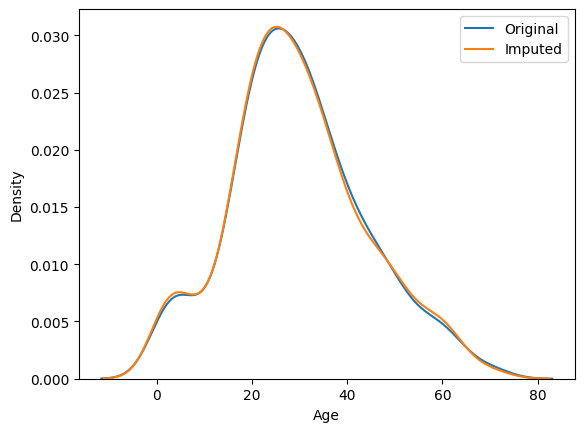

In [34]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show() 
# this is the big achievement 

In [ ]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())
# almost same

Original variable variance:  204.3495133904614
Variance after random imputation:  207.21600423343466


In [ ]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()
# will be different can't be controlled 

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,48.064918
Age,71.512440,204.349513,204.349513
Age_imputed,48.064918,204.349513,207.216004


<Axes: >

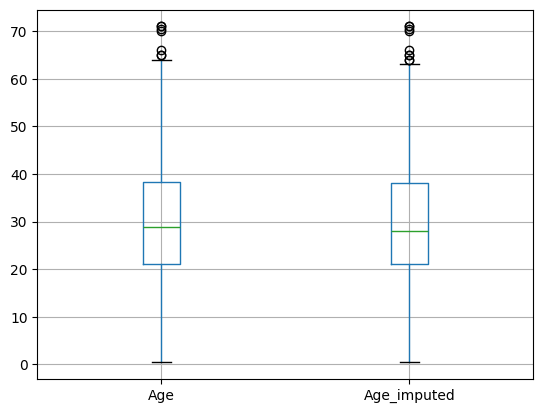

In [37]:
X_train[['Age', 'Age_imputed']].boxplot()

In [ ]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare'])) 
# # do not work but it means that when a fare value 10 come it should select one single age 
# # randomly but always same for that fare 10

NameError: name 'observation' is not defined

# Categorical column


In [41]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [43]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [44]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [ ]:
X=data
y=data['SalePrice'] # b/c ahead we need target column for plotting the graph

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [47]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [48]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
938,NaN,TA,239799,TA,NaN
1176,NaN,TA,119500,TA,NaN
1296,NaN,TA,155000,TA,NaN
309,Ex,TA,360000,TA,Ex
931,NaN,TA,117500,TA,NaN


In [50]:

# X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
# X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

# X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
# X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [51]:
X_train.loc[
    X_train['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = (
    X_train['GarageQual']
    .dropna()
    .sample(X_train['GarageQual_imputed'].isnull().sum())
    .values
)

X_test.loc[
    X_test['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = (
    X_train['GarageQual']
    .dropna()
    .sample(X_test['GarageQual_imputed'].isnull().sum())
    .values
)

X_train.loc[
    X_train['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(X_train['FireplaceQu_imputed'].isnull().sum())
    .values
)

X_test.loc[
    X_test['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = (
    X_train['FireplaceQu']
    .dropna()
    .sample(X_test['FireplaceQu_imputed'].isnull().sum())
    .values
)

In [52]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [53]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.037671
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [54]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.640853
TA,0.412439,0.548822
Fa,0.040917,0.051627
Po,0.027823,0.037037
Ex,0.024550,0.032548


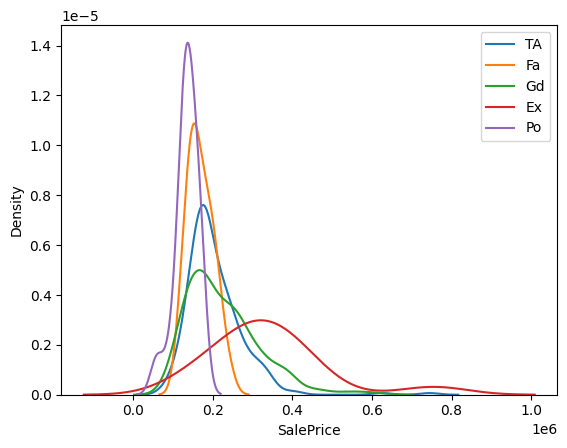

In [60]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()


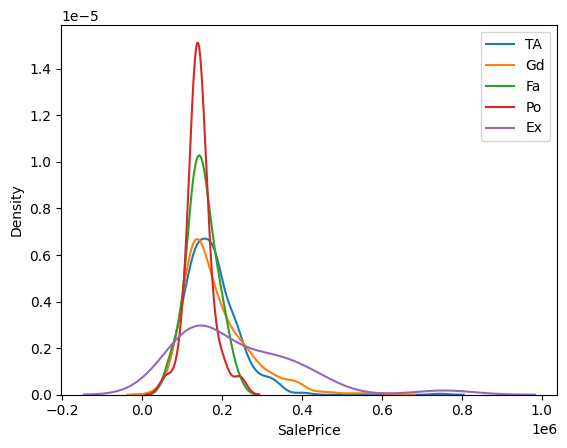

In [61]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()
